<a href="https://colab.research.google.com/github/debchi108/Deep_learning/blob/main/Copy_of_Graph_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Graph Neural Networks**

In [ ]:
# use the correct version of torch!
! pip install torch==2.8.0

# pytorch geometric dependencies:
! pip install torch_geometric

# for gpu installation use this line:
! pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.8.0+cu128.html

# use the following line instead when running on a cpu only machine:
# ! pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.8.0+cpu.html

# dependencies for the molecular data
! pip install ase

Looking in links: https://data.pyg.org/whl/torch-2.8.0+cu128.html


In [ ]:
import torch
import torch_geometric as pyg

import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial.transform import Rotation

# some helper functions for the lab
from utils import load_toy_data, generate_otf_graph
from coll_data import get_coll_loaders, batch_to_atoms

import ase

**## Preliminaries: Data and batching in PyG**

PyG is built on top of PyTorch, and in that sense is very similar to what you have already seen. However, graphs are structured a bit differently compared to, e.g., images. For example, the sizes of different samples can be very different, and a graph consists of different parts like node features, edges, and edge features and unlike for text sequences there is no clear way to truncate the data in order to obtain samples of equal length. PyG helps keep track of and organize this using ```pyg.data.Data``` (for a single instance of a graph) and ```pyg.loader.DataLoader``` (a custom DataLoader for batching data).

### PyTorch Geometric data
First, let's take a look at two toy graphs, illustrated below. The numbers represent indices, and the colors indicate the type of the node.
In the following, we look at some toy data and examine the internals of PyTorch Geometric's data representation.

_Note: If the image below is not showing due to your notebook environment, you can also manually inspect the image file contained in the zip folder that includes all the assignment material._





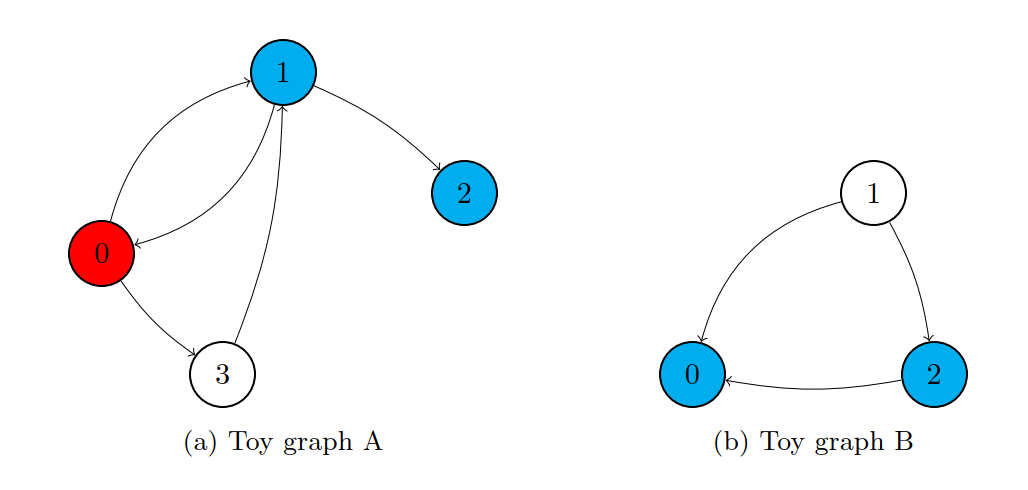

PyG's representations of these can be loaded using ```load_toy_data()``` which returns the two graphs as ```pyg.data.Data``` objects. Run the cells below to print the contents, then answer the questions below about how the graphs are stored in the framework.

In [ ]:
# load the two toy graphs.
data1, data2 = load_toy_data()

In [ ]:
# look at data1 and data2 and their content to answer the question below.
print("data 1")
print(data1)
print(data1.x)
print(data1.edge_index)

print()

print("data 2")
print(data2)
print(data2.x)
print(data2.edge_index)

data 1
Data(x=[4, 1], edge_index=[2, 5])
tensor([[3],
        [2],
        [2],
        [1]])
tensor([[1, 0, 3, 1, 0],
        [0, 1, 1, 2, 3]])

data 2
Data(x=[3, 1], edge_index=[2, 3])
tensor([[2],
        [1],
        [2]])
tensor([[1, 2, 1],
        [0, 0, 2]])


**Question 1:** Which of ```data1``` and ```data2``` correspond to graph A and B? Include a short motivation based on the output of your code.

**Answer:**

### Batching

Now, let's take a look at how batching works in PyG. Create a PyG dataloader with ```data1``` and ```data2``` and
check the content of the resulting batch to answer the two questions below.

In [ ]:
# create dataloader and get the first batch.
dataloader = pyg.loader.DataLoader([data1, data2], batch_size=2)
data_batch = next(iter(dataloader))

In [ ]:
# play around with data_batch
print(data_batch)

print(data_batch.x)
print(data_batch.edge_index)
print(data_batch.batch)

DataBatch(x=[7, 1], edge_index=[2, 8], batch=[7], ptr=[3])
tensor([[3],
        [2],
        [2],
        [1],
        [2],
        [1],
        [2]])
tensor([[1, 0, 3, 1, 0, 5, 6, 5],
        [0, 1, 1, 2, 3, 4, 4, 6]])
tensor([0, 0, 0, 0, 1, 1, 1])


**Question 2**: What is the purpose of the ```batch``` attribute in the ```data_batch``` object? What else is contained in the data batch?

**Answer:**

**Question 3**: What happened to ```edge_index``` when batching the two graphs? Why?

**Answer**:

The dataset that you will work with is a molecular dataset, and as that probably is a new type of application for you, this section aims at giving a brief introduction to how molecules can be represented as graphs.

In the lab, the task of the GNN is to predict the energy $E$ of a molecule consisting of $N$ atoms (nodes). We can describe this mathematically as

$$
\hat{E} = GNN [ \mathbf{Z}, \mathbf{v} ]
$$

where the input data consists of the coordinates of each atom in the molecule $\mathbf{Z} \in \mathbb{R}^{3 \times N}$ and $\mathbf{v} \in \mathbb{Z}^N$ describing the atomic number of each atom in the molecule.
We use the one-hot encoding of the atomic number in order to design the node features of the input graph.
Since there are 118 elements in the periodic table, the one-hot encoded node features are stored in a matrix $\mathbf{X}$ of size $118 \times N$.
The positions of the atoms are used to construct edge features such as the distance length and the direction between the individual atoms.
We can either use the 3-D distance vector between the nodes as the edge features or the length of the distance vector as we will discuss throughout this lab.
This leads to either $D_E = 1$ or $D_E = 3$ depending on which model we use.

From the input to the GNN (consisting of $\mathbf{Z}$ and $\mathbf{v}$), it is rather straightforward to construct a graph: each atom corresponds to a node, and we can create edges between atoms that are within a certain distance from each other. The node features could then be the type of atom, and edge features could incorporate geometric information like distance between the atoms.
Note that in this lab we do not use additional information about the molecule such as the bonds between the individual atoms.

**Question 4**: What kind of task (graph-, node-, edge-level) is the task in this lab? Is it a classification or a regression task?

**Answer**:

## Deriving MPNN equations

There is a wide variety of different GNN layers. The choice of particular scheme depends on many factors such as the application, types of graph and scale of the model.
PyG provides support for the message passing neural network (MPNN) framework. Therefore, it is rather straightforward to implement a GNN if you have derived the functions $m[\cdot, \cdot, \cdot]$ and $u[\cdot, \cdot]$ from the message-passing framework.
Each function can additionally use learnable parameters.

In this lab, you will work with a GNN called [CGCNN](https://arxiv.org/pdf/1710.10324.pdf) and which has been developed for chemistry applications. To implement this model in PyG, we will start by deriving the MPNN equations for CGCNN. In the original paper, they use the equation (compare eq. 5 in the paper with slightly different notation) to compute the output of a single layer:
$$
\mathbf{h}_{k+1}^{(i)}  = \mathbf{h}^{(i)}_{k} + \sum_{j\in \text{ne}[i]} \mathbf{a}_1 \left[ \mathbf{\Omega}_k^{f}\mathbf{z}^{(j, i)}_k + \boldsymbol{\beta}_k^{f} \right] \odot \mathbf{a}_2\left[ \mathbf{\Omega}_k^{s}\mathbf{z}^{(j, i)}_k + \boldsymbol{\beta}_k^{s} \right]
$$
to describe their updates to the node features $\mathbf{h}^{(i)}$ of the corresponding node $i$ and the subscript indicates the number of the hidden layer $k$ that is used. Here, $\mathbf{\Omega}$ and $\boldsymbol{\beta}$ denote weight matrices and vectors and we  use $s$ and $f$ two differentiate between the two sets of weight matrices and bias terms. Each set parameterizes a fully-connected linear layer. The functions $\mathbf{a}_1[\cdot]$ and $\mathbf{a}_2[\cdot]$ are two different non-linear activation functions operating element-wise, $\odot$ means element-wise multiplication, and $\mathbf{z}^{(j, i)} = \mathbf{h}^{(i)} \oplus \mathbf{h}^{(j)} \oplus \mathbf{e}^{(j, i)}$ is the concatenation of node and edge feature vectors.

_Note that in this notebook we use $\text{ne}[i]$ in order to denote the neighbourhood of node $i$ as done in the course book rather than $\mathcal{N}_i$._.

**Question 5**: Given the equation above, re-write this according to the general MPNN-equations from the lectures. How are the incoming messages aggregated in the CGCNN network?


**Answer**: _You can either write the equations in latex here or present the solution to us in handwritten form._

## Implementing a CGCNN layer
Now it is time to put these equations into practice and create a CGCNN layer, using the ```MessagePassing``` class from PyG.

It might help to read through the **intro** and the **part about the Message Passing base class** in the PyG [tutorial](https://pytorch-geometric.readthedocs.io/en/latest/notes/create_gnn.html).

**Note**: the function ```MessagePassing.update()``` is, according to the developers, being phased out. In this lab we therefore perform the update step inside ```forward()``` after calling ```propagate()```.

Then implement the equations that you derived. In the CGCNN paper, it is specified that $\mathbf{a}_1[\cdot] = \text{sigmoid}[\cdot]$ to implement a _gating_ mechanism. For $\mathbf{a}_2[\cdot]$, we can use $\text{softplus}[\cdot]$ for the activation functions.

**Task 1**: Implement the derived message passing equations in the CGCNN layer in the Message Passing class below. The ```message()``` method implements message computation. By calling ```propagate()``` in ```forward()```, messages are computed and aggregated using the selected aggregation function.


**Task 2**: In order to get good performance later during the lab, add a BatchNorm both after computing the linear part of the messages and after the aggregation of the messages.


Step 1 — __init__: Setting up the layers:  

In [ ]:
class CGCNNLayer(pyg.nn.MessagePassing):

    def __init__(self, node_fea_dim, edge_fea_dim):
        # "sum" because CGCNN aggregates messages by summing them
        super().__init__(aggr="sum")

        # z is the concatenation of h_i, h_j, and e
        # so its size = node_fea_dim + node_fea_dim + edge_fea_dim
        z_dim = 2 * node_fea_dim + edge_fea_dim

        # Linear layer for the gate (a1 = sigmoid) — Ω^f and β^f
        self.linear_f = torch.nn.Linear(z_dim, node_fea_dim)

        # Linear layer for the content (a2 = softplus) — Ω^s and β^s
        self.linear_s = torch.nn.Linear(z_dim, node_fea_dim)

        # TWO SEPARATE BatchNorms — one for gate, one for content
        self.bn_f = torch.nn.BatchNorm1d(node_fea_dim)  # for gate input
        self.bn_s = torch.nn.BatchNorm1d(node_fea_dim)  # for content input

        # BatchNorm AFTER aggregation (on the summed messages)
        self.bn_aggregation = torch.nn.BatchNorm1d(node_fea_dim)

        # Activation functions
        self.sigmoid = torch.nn.Sigmoid()    # a1 → gate
        self.softplus = torch.nn.Softplus()  # a2 → content

    def forward(self, h, edge_index, edge_attr):
        # propagate() automatically calls message() for every edge
        # and aggregates using "sum" as defined in __init__
        m = self.propagate(edge_index, h=h, e=edge_attr)

        # BatchNorm after aggregation
        m = self.bn_aggregation(m)

        # Residual update: keep old features + add the messages
        out = h + m

        return out

    def message(self, h_i, h_j, e):
        # h_i = features of the receiving node
        # h_j = features of the sending neighbour
        # e   = edge features between them

        # Step 1: concatenate h_i, h_j, e into z
        z = torch.cat([h_i, h_j, e], dim=1)

        # Step 2: pass through both linear layers
        gate_input    = self.linear_f(z)  # Ω^f * z + β^f
        content_input = self.linear_s(z)  # Ω^s * z + β^s

        # Step 3: each gets its OWN separate BatchNorm
        gate_input    = self.bn_f(gate_input)    # BN for gate only
        content_input = self.bn_s(content_input) # BN for content only

        # Step 4: apply activation functions
        gate    = self.sigmoid(gate_input)     # a1[...] → values 0 to 1
        content = self.softplus(content_input) # a2[...] → smooth values

        # Step 5: element-wise multiply ⊙
        # gate controls HOW MUCH of content passes through
        return gate * content

**Question 6**: How many parameters does the network layer have for node features with dimension 10 and edge features with dimension 5?

**Answer**:

## CGCNN Network
Now once we have implemented the layer, we can use it in a full CGCNN model. This is still a ```torch.nn.Module``` (so nothing new just because we are working with GNNs), but the layers will be instances of your ```CGCNNLayer``` from before.

The forward pass through the model should compute the following steps:

1. Embed the nodes into node features
1. Iterate over the CGCNN layers
    1. Pass through the layer
    1. Batch norm
    1. Activation function (for example, softplus)
1. Pool node features using mean pooling
1. Pass pooled representation through final MLP

As this is a graph-level task, we need to pool node information into a single global representation (one vector per graph). To perform the pooling of node features, PyG provides [pooling layers](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#pooling-layers). CGCNN uses mean pooling, so take a look at the documentation of [pyg.nn.pool.global_mean_pool](https://pytorch-geometric.readthedocs.io/en/latest/generated/torch_geometric.nn.pool.global_mean_pool.html#torch_geometric.nn.pool.global_mean_pool).

**Task 3**: Implement the forward pass through the model in the created network.

In [ ]:
class CGCNN(torch.nn.Module):

    def __init__(self, node_fea_dim, invariant, num_layers, cutoff, max_neighbors):
        super().__init__()

        # parameters to generate the graph from the molecular structure
        self.cutoff = cutoff
        self.max_neighbors = max_neighbors
        self.pbc = False  # Keep this when using the COLL dataset

        # the invariant model uses one edge feature, the regular three.
        if invariant:
            edge_fea_dim = 1
        else:
            edge_fea_dim = 3
        self.edge_fea_dim = edge_fea_dim

        # Embedding table: maps atom type number → node feature vector
        # 118 = number of elements in the periodic table
        # Create an embedding layer (number of elements in embedding table=118)
        self.embed = torch.nn.Embedding(118, node_fea_dim)

        # Stack of CGCNNLayers + BatchNorm layers
        # Initialize the cgcnn layers, batch norm layers, and choose an activation function
        self.cgcnn_layers = torch.nn.ModuleList([CGCNNLayer(node_fea_dim, edge_fea_dim) for _ in range(num_layers)])
        self.bn_layers = torch.nn.ModuleList([torch.nn.BatchNorm1d(node_fea_dim) for _ in range(num_layers)])
        self.activation = torch.nn.Softplus()

        # Pool function
        # Global mean pooling — averages node features per graph
        self.pool = pyg.nn.pool.global_mean_pool

        # Create a small MLP that can take in the pooled representation, and output a prediction of the energy
        # Final MLP: pooled vector → single energy prediction
        self.out_mlp = torch.nn.Sequential(torch.nn.Linear(node_fea_dim, 2*node_fea_dim),
                                     torch.nn.Softplus(),

                                           torch.nn.Linear(2*node_fea_dim, 1))

    def forward(self, data):
        # For this data, we construct the graph on the fly, but it is possible for other datasets to have data.edge_index, data.edge_attr etc
        # Build the graph on the fly from atom positions
        # edge_index: which atoms are connected
        # edge_dist: distance between connected atoms (scalar)
        # distance_vec: 3D vector between connected atoms
        edge_index, edge_dist, distance_vec = generate_otf_graph(data, self.cutoff, self.max_neighbors, self.pbc)

        # Make edge_dist a 2D tensor: [num_edges, 1]
        edge_dist = edge_dist.unsqueeze(-1)

         # Choose edge features based on invariant or not
        if self.edge_fea_dim == 1:
            edge_attr = edge_dist # just distance — invariant!
        else:
            edge_attr = distance_vec # full 3D vector — not invariant

        # TODO: implement the forward pass through the network
        # Step 1: embed atom types into node feature vectors
        # data.atomic_numbers contains the atom type (e.g., 6 for Carbon)
        h = self.embed(data.atomic_numbers)

        # Step 2: pass through all CGCNN layers
        for layer, bn in zip(self.cgcnn_layers, self.bn_layers):
            h = layer(h, edge_index, edge_attr)  # message passing
            h = bn(h)                             # batch normalisation
            h = self.activation(h)                # softplus activation

        # Step 3: pool all node features → one vector per graph
        # data.batch tells us which graph each node belongs to
        h = self.pool(h, data.batch)

        # Step 4: MLP predicts the energy from the pooled representation
        prediction = self.out_mlp(h)


        # make sure the dimensions are the same
        return prediction.squeeze()


### Invariance
The task for the GNN in this lab is to predict the energy of the molecular system. This property is __invariant__ to any rigid transformations (i.e., rotations and/or translations) of the molecules; it does not matter if we move the molecule to a different position, or if it is rotated, it is still the same molecule with the same energy.

We can make the network invariant to such transformations by using only invariant features. The input to CGCNN consists of the atom types $\mathbf{v}$ from which the node features are constructed using a one-hot encoding and the atom positions $\mathbf{Z}$. The atom types are of course invariant to translations and rotations, so it is the geometric information in $\mathbf{Z}$ that needs consideration. CGCNN incorporates this geometric information in the edge features. Consider using as edge feature either 1) the distance between the two atoms or 2) the (three-dimensional) vector between the atoms.

**Question 7:** To what transformations (rotations, translations) are these respective features invariant?

**Answer**:

Now let's take a look at this in practice. Load some data and use ```transform_and_visualize``` to apply a rotation and see how the visualization changes.

**Note**: the dataset we are working on in this lab is called COLL. You do not have to implement the dataset yourself, but PyG provides a custom dataset class called ```InMemoryDataset``` in which COLL has been implemented for this lab. If you are interested in how such a dataset could be constructed, you can take a look at ```coll_data.py``` to see the implementation, and you can read more in the [PyG tutorial on creating graph datasets](https://pytorch-geometric.readthedocs.io/en/latest/tutorial/create_dataset.html).

In [ ]:
def transform_and_visualize(data):
    transformed_data = data.clone()
    rot_vec = np.array([1.0, 1.0, 0.0])
    rot_vec = rot_vec / np.linalg.norm(rot_vec)
    rot_angle = np.pi/3
    rotation_matrix = torch.tensor(Rotation.from_rotvec(rot_angle * rot_vec).as_matrix()).float()
    transformed_data.pos = torch.matmul(transformed_data.pos, rotation_matrix)
    fig, ax = plt.subplots(1, 2)
    atoms = batch_to_atoms(data)
    transformed_atoms = batch_to_atoms(transformed_data)

    ase.visualize.plot.plot_atoms(atoms[0], ax[0], rotation=("-75x, 45y, 10z"))
    ase.visualize.plot.plot_atoms(transformed_atoms[0], ax[1], rotation=("-75x, 45y, 10z"))

    ax[0].set_title("Original data")
    ax[1].set_title("Rotated data")
    plt.show()

    return data, transformed_data

Processing...
Done!
Processing...
Done!
Processing...
Done!


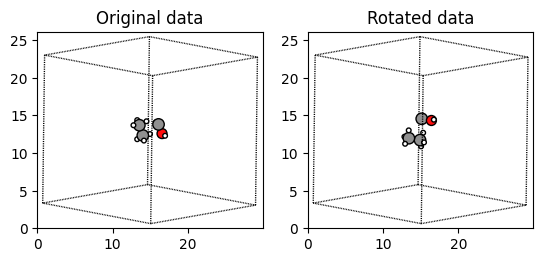

In [ ]:
_, loader, _ = get_coll_loaders(5)  # returns train, val, test loaders. For now just using the val loader

data = next(iter(loader))
data, transformed_data = transform_and_visualize(data)

Now try instantiating a model that uses these different edge features by setting ```edge_fea_dim=1``` (only distances) or ```edge_fea_dim=3``` (vector between atoms), and make predictions for both ```data``` and ```transformed_data```.

In [ ]:
# Reasonable values for cutoff and max_neighbors are 12 [Å] and 30, respectively. For now, number of layers doesn't matter
model_ = CGCNN(32, False, 5, 12, 30) # non-invariant (3D vector)
model_invariant = CGCNN(32, True, 5, 12, 30) # invariant (distance only)

# disable gradient computations here:
with torch.no_grad():

    print("Regular model:")
    print("Output:\t\t\t", model_(data), "\nOutput transformed:\t", model_(transformed_data))

    print()
    print("Invariant model:")
    print("Output:\t\t\t", model_invariant(data), "\nOutput transformed:\t", model_invariant(transformed_data))

Regular model:
Output:			 tensor([-0.4344, -0.5353, -0.4426, -0.4338, -0.4440]) 
Output transformed:	 tensor([-0.4363, -0.5368, -0.4437, -0.4292, -0.4392])

Invariant model:
Output:			 tensor([0.2641, 0.4715, 0.3648, 0.3534, 0.3539]) 
Output transformed:	 tensor([0.2641, 0.4715, 0.3648, 0.3534, 0.3539])


**Question 8:** What do you see in the outputs? Is it what you expected?

**Answer**:

## Task 4: Train a CGCNN model

In [ ]:
device = "cuda" # todo: change to cuda if you are using gpu support.

Step 1 — Load the data:

In [ ]:
train_loader, val_loader, test_loader = get_coll_loaders(256)

Step 2 — Train the invariant model:

In [ ]:
@torch.inference_mode()
def validate(model, loader, device):
    assert not model.training, "Model is in training mode"
    num_samples = 0
    total_sq_error = 0
    total_abs_error = 0

    for i, batch in enumerate(loader):
        batch = batch.to(device)
        batch_size = batch.y.shape[0]
        num_samples += batch_size

        pred = model(batch)
        mae = torch.nn.functional.l1_loss(pred, batch.y)
        mse = torch.nn.functional.mse_loss(pred, batch.y)

        total_sq_error += mse.item()*batch_size
        total_abs_error += mae.item()*batch_size

    avg_mse = total_sq_error / num_samples
    avg_mae = total_abs_error / num_samples
    return avg_mse, avg_mae

def train_and_test(model, optimizer, loss_fn, train_loader, val_loader, num_epochs=10, device="cuda", save_name="best_parameters.pt", test_loader=None):
    model = model.to(device)
    best_val_error = 1e9

    losses = []
    val_errors = []

    for epoch in range(num_epochs):
        model.train(True)

        epoch_losses = []
        for i, batch in enumerate(train_loader):
            optimizer.zero_grad()
            batch = batch.to(device)

            pred = model(batch)
            loss = loss_fn(pred, batch.y)

            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        mean_epoch_loss = np.mean(epoch_losses)
        print(f"Epoch {epoch+1} training loss: \t {mean_epoch_loss:.4f}")

        # Validation
        model.train(False)
        val_mse, val_mae = validate(model, val_loader, device)
        print(f"Epoch {epoch+1} validation MSE: {val_mse:.4f} \t MAE: {val_mae:.4f}")
        if val_mae < best_val_error:  # we choose MAE as preferred metric
            torch.save(model.state_dict(), save_name)  # save these model parameters
            best_val_error = val_mae

        # store validation error and training loss for visualization later
        val_errors.append((val_mae, val_mse))
        losses.append(mean_epoch_loss)

    print("Training finished!")
    model.train(False)

    if test_loader is not None:
        print("Evaluating on test set")
        model.load_state_dict(torch.load(save_name, weights_only=False))  # load best parameters, based on validation error (early stopping)
        test_mse, test_mae = validate(model, test_loader, device)
        print(f"Final test MSE: {test_mse:.4f}, \t MAE {test_mae:.4f}")

    return losses, val_errors, (test_mse, test_mae)


Start training: ### Invariant model
Now it is time to train a model. Start with a completely invariant model (```edge_fea_dim=1```). After loading the data, initialize your model, choose an optimizer and loss function.

In [ ]:
# Reasonable values for cutoff and max_neighbors are 12 [Å] and 30 max neighbours, respectively.
model_inv = CGCNN(node_fea_dim=32, invariant=True, num_layers=3, cutoff=12, max_neighbors=30)

# choose optimizer and loss function.
optimizer = torch.optim.AdamW(model_inv.parameters(), lr=0.0001)
loss_fn = torch.nn.L1Loss()

# run the training loop.
train, val, test = train_and_test(model_inv, optimizer, loss_fn, train_loader, val_loader, 30, device, "best_parameters_invariant.pt", test_loader)

Epoch 1 training loss: 	 1.2363
Epoch 1 validation MSE: 0.0999 	 MAE: 0.2050
Epoch 2 training loss: 	 0.1941
Epoch 2 validation MSE: 0.0891 	 MAE: 0.1909
Epoch 3 training loss: 	 0.1856
Epoch 3 validation MSE: 0.0838 	 MAE: 0.1832
Epoch 4 training loss: 	 0.1798
Epoch 4 validation MSE: 0.0817 	 MAE: 0.1827
Epoch 5 training loss: 	 0.1751
Epoch 5 validation MSE: 0.0812 	 MAE: 0.1856
Epoch 6 training loss: 	 0.1720
Epoch 6 validation MSE: 0.0740 	 MAE: 0.1724
Epoch 7 training loss: 	 0.1686
Epoch 7 validation MSE: 0.0725 	 MAE: 0.1682
Epoch 8 training loss: 	 0.1668
Epoch 8 validation MSE: 0.0709 	 MAE: 0.1680
Epoch 9 training loss: 	 0.1647
Epoch 9 validation MSE: 0.0700 	 MAE: 0.1654
Epoch 10 training loss: 	 0.1628
Epoch 10 validation MSE: 0.0811 	 MAE: 0.1921
Epoch 11 training loss: 	 0.1617
Epoch 11 validation MSE: 0.0713 	 MAE: 0.1805
Epoch 12 training loss: 	 0.1601
Epoch 12 validation MSE: 0.0687 	 MAE: 0.1690
Epoch 13 training loss: 	 0.1588
Epoch 13 validation MSE: 0.0651 	 MAE

Step 3 — Train the non-invariant model
### Not using an invariant model
Now compare this to a model that is not completely invariant (i.e., ```edge_fea_dim=3```)

In [ ]:
# use same setup as before, only change type of edge features
model = CGCNN(node_fea_dim=32, invariant=False, num_layers=3, cutoff=12, max_neighbors=30)

optimizer = torch.optim.AdamW(model.parameters(), lr=0.0001)
loss_fn = torch.nn.L1Loss()

train_ninv, val_ninv, test_ninv = train_and_test(model, optimizer, loss_fn, train_loader, val_loader, 30, device, "best_parameters_non_invariant.pt", test_loader)

Epoch 1 training loss: 	 1.7059
Epoch 1 validation MSE: 0.1107 	 MAE: 0.2230
Epoch 2 training loss: 	 0.2064
Epoch 2 validation MSE: 0.1001 	 MAE: 0.2051
Epoch 3 training loss: 	 0.2013
Epoch 3 validation MSE: 0.0960 	 MAE: 0.2014
Epoch 4 training loss: 	 0.1976
Epoch 4 validation MSE: 0.0955 	 MAE: 0.2013
Epoch 5 training loss: 	 0.1955
Epoch 5 validation MSE: 0.0937 	 MAE: 0.2060
Epoch 6 training loss: 	 0.1933
Epoch 6 validation MSE: 0.0907 	 MAE: 0.1991
Epoch 7 training loss: 	 0.1918
Epoch 7 validation MSE: 0.0905 	 MAE: 0.1961
Epoch 8 training loss: 	 0.1899
Epoch 8 validation MSE: 0.0874 	 MAE: 0.1937
Epoch 9 training loss: 	 0.1881
Epoch 9 validation MSE: 0.0849 	 MAE: 0.1890
Epoch 10 training loss: 	 0.1869
Epoch 10 validation MSE: 0.0868 	 MAE: 0.1917
Epoch 11 training loss: 	 0.1854
Epoch 11 validation MSE: 0.0839 	 MAE: 0.1902
Epoch 12 training loss: 	 0.1840
Epoch 12 validation MSE: 0.0810 	 MAE: 0.1838
Epoch 13 training loss: 	 0.1832
Epoch 13 validation MSE: 0.0808 	 MAE

### Plotting the performance:

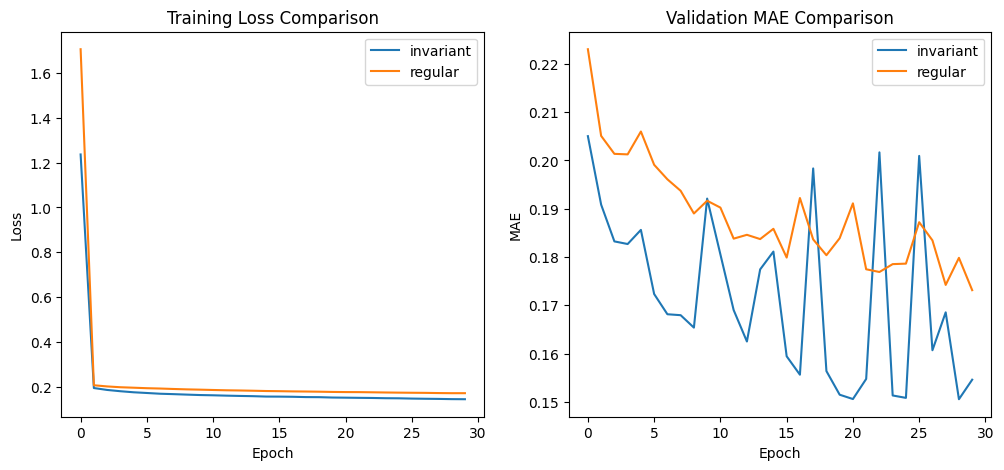

In [ ]:
# plot the training loss and validation MAE curves for both models to compare their performance.
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

plt.plot(train, label="invariant")
plt.plot(train_ninv, label="regular")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")

plt.subplot(1, 2, 2)
plt.plot([x[0] for x in val], label="invariant")
plt.plot([x[0] for x in val_ninv], label="regular")

plt.legend()
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Validation MAE Comparison")
plt.show()

**Question 9:** Do you see any differences in performance compared to the invariant model? Why do you think that is the case?

**Answer**:

**Question 10:** In this case we could make the model invariant by design. If that is not possible, could you think of some other option(s) for making a model more robust to transformations of the input? (Apart from transformations discussed in this lab, another example could be to make a CNN robust to rotations of an image, e.g., a cat is always a cat, even if it is upside down)

**Answer**:

Now, we can use the trained model in order to predict the energy of the molecule: below there are three molecules and their rotated version. For each of the samples we can print the predictions obtained from our two different models and compare them to the ground truth.

**Task**: Apply the trained models to some of the test datapoints and compare the predicted energy level to the ground truth. You can also check the performance on the transformed data to observe the different behavior of the models on this.

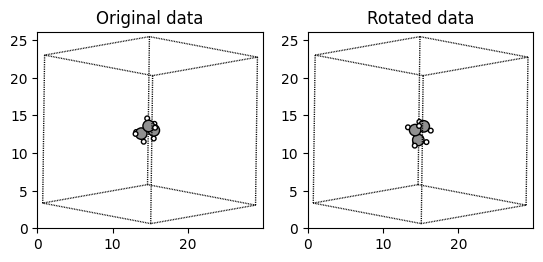

In [ ]:
_, _, test_loader = get_coll_loaders(10)  # returns train, val, test loaders. only take the test data

data = next(iter(test_loader))
data, transformed_data = transform_and_visualize(data)

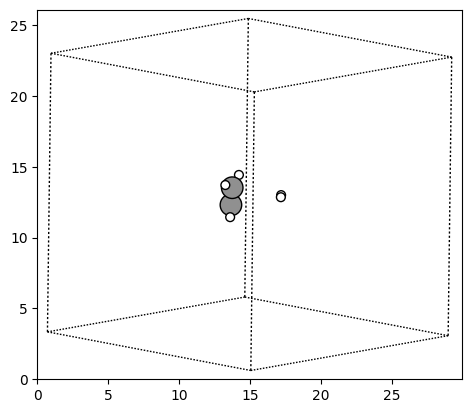

Predicted energy regular model:		 -3.2361621856689453
Predicted energy invariant model:	 -3.186249017715454

True energy of molecule:		 -3.364109754562378


In [ ]:
# choose the sample from the batch (batch_size = 10)
i = 1

# plot the atoms
atoms = batch_to_atoms(data)
ase.visualize.plot.plot_atoms(atoms[i], rotation=("-75x, 45y, 10z"))
plt.show()

# compare the prediction with the true label
data = data.to(device)
print("Predicted energy regular model:\t\t", model(data)[i].item())
print("Predicted energy invariant model:\t", model_inv(data)[i].item())
print()
print("True energy of molecule:\t\t", data.y[i].item())